In [231]:
import numpy as np
import pandas as pd


In [232]:
data=pd.read_csv(r"C:\Users\ASUS\Downloads\realistic_employee_attrition.csv")
df=pd.DataFrame(data)

In [233]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Age               100000 non-null  int64  
 1   JobLevel          100000 non-null  int64  
 2   MonthlyIncome     100000 non-null  float64
 3   YearsAtCompany    100000 non-null  int64  
 4   StockOptionLevel  100000 non-null  int64  
 5   DistanceFromHome  100000 non-null  int64  
 6   OverTime          100000 non-null  str    
 7   WorkLifeBalance   100000 non-null  int64  
 8   JobSatisfaction   100000 non-null  int64  
 9   Attrition         100000 non-null  str    
dtypes: float64(1), int64(7), str(2)
memory usage: 8.1 MB


In [234]:
df.duplicated().sum()

np.int64(22)

In [235]:
df.shape

(100000, 10)

In [236]:
df=df.drop_duplicates()

In [237]:
df.shape

(99978, 10)

In [238]:
df.isna().sum()

Age                 0
JobLevel            0
MonthlyIncome       0
YearsAtCompany      0
StockOptionLevel    0
DistanceFromHome    0
OverTime            0
WorkLifeBalance     0
JobSatisfaction     0
Attrition           0
dtype: int64

In [239]:
df.columns.to_list()

['Age',
 'JobLevel',
 'MonthlyIncome',
 'YearsAtCompany',
 'StockOptionLevel',
 'DistanceFromHome',
 'OverTime',
 'WorkLifeBalance',
 'JobSatisfaction',
 'Attrition']

In [240]:
df.columns=df.columns.str.strip()

In [241]:
print(df["Attrition"].value_counts())
print(df["OverTime"].value_counts())

Attrition
No     49995
Yes    49983
Name: count, dtype: int64
OverTime
No     81771
Yes    18207
Name: count, dtype: int64


In [242]:
columns=["OverTime","Attrition"]
for col in columns:
    df[col]=df[col].replace({
        "Yes":1,
        "No":0
    })


In [243]:
df.head(20)

,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
0,44,4,13544.0,3,3,1,0,3,4,0
1,44,4,13296.0,3,3,21,0,4,4,0
2,32,3,8894.0,3,2,4,1,2,2,1
3,29,1,3442.0,0,0,2,0,4,4,0
4,52,5,20906.0,10,3,21,0,3,4,0
5,31,3,8376.0,1,2,5,0,4,3,0
6,30,4,13278.0,2,3,9,0,4,4,0
7,35,4,14803.0,7,3,14,0,4,4,0
8,31,4,13806.0,4,2,3,0,4,2,0
9,28,2,5332.0,0,1,8,0,4,4,0


In [244]:
max_values=pd.DataFrame({
    "MonthlyIncome":[df["MonthlyIncome"].max()],
    "DistanceFromHome":[df["DistanceFromHome"].max()],
    "WorkLifeBalance":[df["WorkLifeBalance"].max()]
})
max_values

,MonthlyIncome,DistanceFromHome,WorkLifeBalance
0,23636.0,29,4


In [245]:
from sklearn.preprocessing import StandardScaler

# Define the columns that have large continuous ranges
cols_to_scale = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']

scaler = StandardScaler()

# Fit and transform the specific columns in your dataframe
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [246]:
correlation_matrix=df.corr()
correlation_matrix


,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
Age,1.000000,0.613622,0.633052,0.573472,0.532323,-0.000491,-0.044907,0.027552,0.387122,-0.417359
JobLevel,0.613622,1.000000,0.977658,0.579085,0.866505,-0.001557,-0.075681,0.046997,0.600792,-0.662040
MonthlyIncome,0.633052,0.977658,1.000000,0.656788,0.847209,-0.002847,-0.063451,0.039011,0.607552,-0.648226
YearsAtCompany,0.573472,0.579085,0.656788,1.000000,0.501900,-0.001047,-0.037734,0.022712,0.390920,-0.408707
StockOptionLevel,0.532323,0.866505,0.847209,0.501900,1.000000,-0.001938,-0.063826,0.038647,0.518654,-0.629241
DistanceFromHome,-0.000491,-0.001557,-0.002847,-0.001047,-0.001938,1.000000,0.044821,-0.029000,-0.014057,0.071039
OverTime,-0.044907,-0.075681,-0.063451,-0.037734,-0.063826,0.044821,1.000000,-0.671568,-0.301308,0.324250
WorkLifeBalance,0.027552,0.046997,0.039011,0.022712,0.038647,-0.029000,-0.671568,1.000000,0.427395,-0.375279
JobSatisfaction,0.387122,0.600792,0.607552,0.390920,0.518654,-0.014057,-0.301308,0.427395,1.000000,-0.758841
Attrition,-0.417359,-0.662040,-0.648226,-0.408707,-0.629241,0.071039,0.324250,-0.375279,-0.758841,1.000000


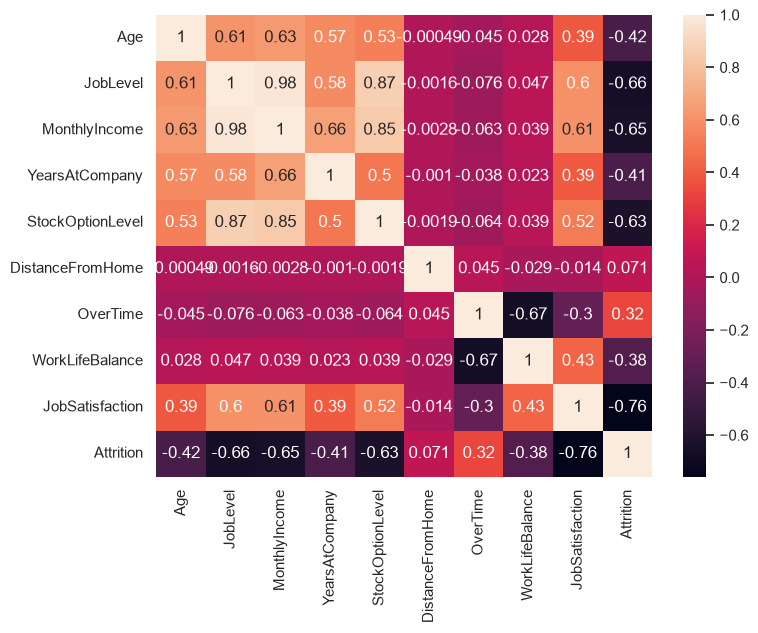

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20312\2206907014.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0, 1], palette='Set2')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20312\2206907014.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', ax=axes[1, 1], palette='Set2')


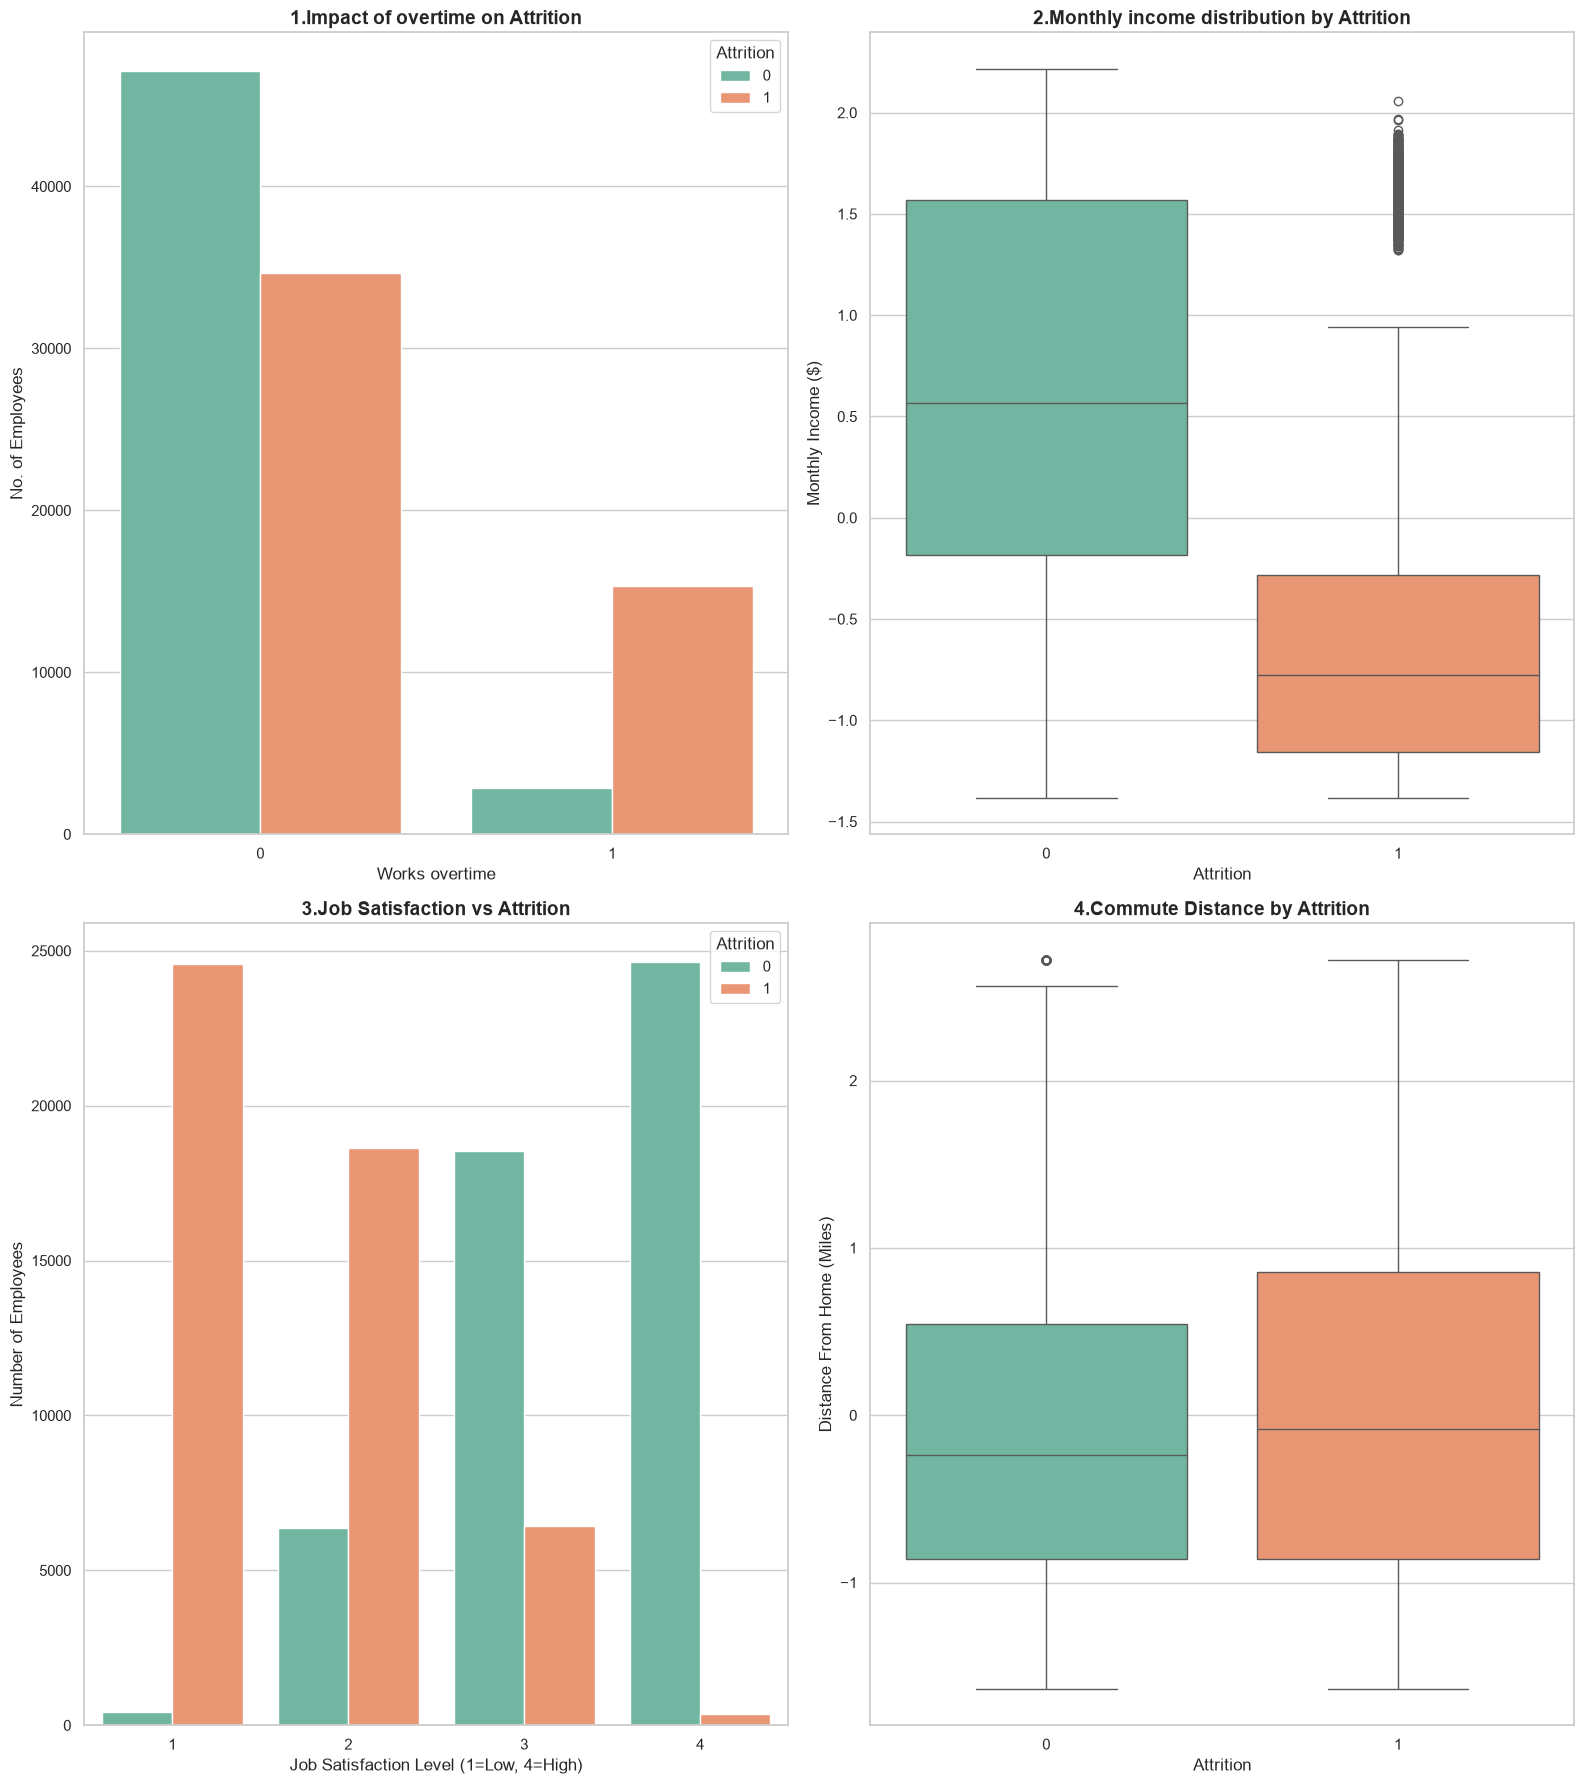

In [248]:
fig,axes=plt.subplots(2,2,figsize=(16,18))
sns.set_theme(style="whitegrid")
sns.countplot(data=df,x='OverTime',hue='Attrition',ax=axes[0,0],palette='Set2')
axes[0,0].set_title('1.Impact of overtime on Attrition', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Works overtime')
axes[0,0].set_ylabel('No. of Employees')
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0, 1], palette='Set2')
axes[0,1].set_title('2.Monthly income distribution by Attrition', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Attrition')
axes[0,1].set_ylabel('Monthly Income ($)')
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1, 0], palette='Set2')
axes[1,0].set_title('3.Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Job Satisfaction Level (1=Low, 4=High)')
axes[1,0].set_ylabel('Number of Employees')
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', ax=axes[1, 1], palette='Set2')
axes[1,1].set_title('4.Commute Distance by Attrition', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Distance From Home (Miles)')
plt.tight_layout()
plt.show()

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop('Attrition', axis=1)
y=df['Attrition']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
continuous_cols=["Age","MonthlyIncome","YearsAtCompany","DistanceFromHome"]
for col in continuous_cols:
    Q1=X_train[col].quantile(0.25)
    Q3=X_train[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    uppr_bound=Q3+1.5*IQR
    outliers=X_train[(X_train[col]<lower_bound)|(X_train[col]>uppr_bound)].shape[0]
    print(f"Found {outliers} outliers in {col}")

Found 0 outliers in Age
Found 0 outliers in MonthlyIncome
Found 3347 outliers in YearsAtCompany
Found 0 outliers in DistanceFromHome


In [250]:
Q1=X_train['YearsAtCompany'].quantile(0.25)
Q3=X_train['YearsAtCompany'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
mask=(X_train['YearsAtCompany']>=lower_bound)&(X_train['YearsAtCompany']<=upper_bound)
X_train=X_train[mask]
y_train=y_train[mask]
print(f"Outliers removed and X_train shape: {X_train.shape}")
print(f"New y_train shape: {y_train.shape}")

Outliers removed and X_train shape: (76635, 9)
New y_train shape: (76635,)


In [251]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from xgboost import XGBClassifier

In [252]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (79982, 9)
X_test shape: (19996, 9)
y_train shape: (79982,)
y_test shape: (19996,)


In [253]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [254]:
xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.001,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [255]:
y_pred = xgb_model.predict(X_test)

In [256]:
accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.9246849369873975


In [257]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9231  768]
 [ 738 9259]]


In [258]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [259]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      9999
           1       0.92      0.93      0.92      9997

    accuracy                           0.92     19996
   macro avg       0.92      0.92      0.92     19996
weighted avg       0.92      0.92      0.92     19996



In [260]:
y_train_pred = xgb_model.predict(X_train)

In [261]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

Training Accuracy: 0.9253206971568603
Testing Accuracy: 0.9246849369873975
Difference: 0.0006357601694627624
